Code to generate Figure 5subplots

In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from tqdm import trange
import matplotlib.ticker as ticker
import seaborn as sns
import networkx as nx

DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../flatten/processed-data/"
DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [3]:
# load the datasets with node centrality information and get nodes in both
#ms_nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")
#y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step18.csv")
nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")

# --- Flip sign of cagiada-dG so downstream code uses the corrected values ---
nodes["cagiada-dG"] = -nodes["cagiada-dG"]

#y2h_nodes = y2h_nodes.merge(abundance_df, on="node", how="left")

#shared_nodes = set(ms_nodes["node"]) & set(y2h_nodes["node"])
#print (f"A total of {len(shared_nodes)} nodes are shared between the MS and Y2H networks")
#list(nodes.columns)

In [4]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [5]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = filtered_nodes['degree_centrality'].quantile(1 - cut)
ms_hubs     = filtered_nodes[filtered_nodes['degree_centrality'] >= ms_threshold]
ms_nothub   = filtered_nodes[filtered_nodes['degree_centrality'] <  ms_threshold]

#y2h_threshold = filtered_nodes['Y2H_degree_centrality'].quantile(1 - cut)
#y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold]
#y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
#print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.01503; there are 252 hubs and 2214 non hubs


In [7]:
# Step 2.1: Load chaperone data
# Parse the interacting_chaperones column if it's a string representation of a list
nodes['interacting_chaperones'] = nodes['interacting_chaperones'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Compute number of chaperone interactions
nodes['num_chaperone_interactions'] = nodes['interacting_chaperones'].apply(len)

# Step 2.2: Build the PPI network to get total degrees
f_ms_edges = pd.read_csv(f"{DATA_PATH1}The_Yeast_Interactome_edges.csv")
f_ms_edges = f_ms_edges.rename(columns={"source": "node1", "target": "node2"})

G = nx.from_pandas_edgelist(f_ms_edges, "node1", "node2", create_using=nx.Graph())

degree_dict = dict(G.degree())
degree_df = pd.DataFrame({
    "node": list(degree_dict.keys()),
    "total_degree": list(degree_dict.values())
})

# Step 2.3: Merge degree and compute chaperone fraction
#Now every protein has: number of chaperone contacts, total degree, fraction of interactions involving chaperones
merged_df = nodes.merge(degree_df, left_on="node", right_on="node", how="inner")
merged_df = merged_df[merged_df['total_degree'] > 0] # avoid divide-by-zero
merged_df['chaperone_fraction'] = (merged_df['num_chaperone_interactions'] / merged_df['total_degree'])

# Step 2.4: Integrate classifications
class_df = filtered_nodes[['node', 'in_complex']].copy()

# Hub assignment
class_df['is_hub'] = class_df['node'].isin(ms_hubs['node'])

# Define hub type:
# static  = hub & in_complex == True
# dynamic = hub & in_complex == False
# nonhub  = everything else
def assign_hub_type(row):
    if row['is_hub']:
        return "static" if row['in_complex'] else "dynamic"
    else:
        return "nonhub"

class_df['hub_type'] = class_df.apply(assign_hub_type, axis=1)

# Merge classification into merged_df
final_df = merged_df.merge(
    class_df[['node', 'is_hub', 'hub_type']],
    on='node',
    how='left'
)

#print(final_df.head())

In [9]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

#Compute hub + chaperone groups for Ghosh–Dill ΔG
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (degree-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Ghosh–Dill values
hub_df["Ghosh_clean"] = hub_df["Ghosh-Dill-dG"].replace([np.inf, -np.inf], np.nan)

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Ghosh_clean"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Ghosh_clean"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

print(f"Hub + Chaperone: n={len(hub_chap)}")
print(f"Hub + No Chaperone: n={len(hub_nochap)}")

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Hub + Chaperone: n=82
Hub + No Chaperone: n=170


Bootstrapping medians: 100%|███████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 73955.63it/s]


Hub + Chaperone: median=-7.15, 95% CI=(-8.14, -6.82), n=82)


Bootstrapping medians: 100%|███████████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 69538.06it/s]

Hub + No Chaperone: median=-8.45, 95% CI=(-9.03, -8.09), n=170)


In [12]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Ghosh-Dill-dG ===")

print("\nHub + Chaperone vs Hub + NoChaperone")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Ghosh-Dill-dG ===

Hub + Chaperone vs Hub + NoChaperone
n(chap) = 82, n(nochap) = 170
median(chap) = -7.15, median(nochap) = -8.45
U = 8268.00, p = 0.01669


/tmp/ipykernel_1324/253594953.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


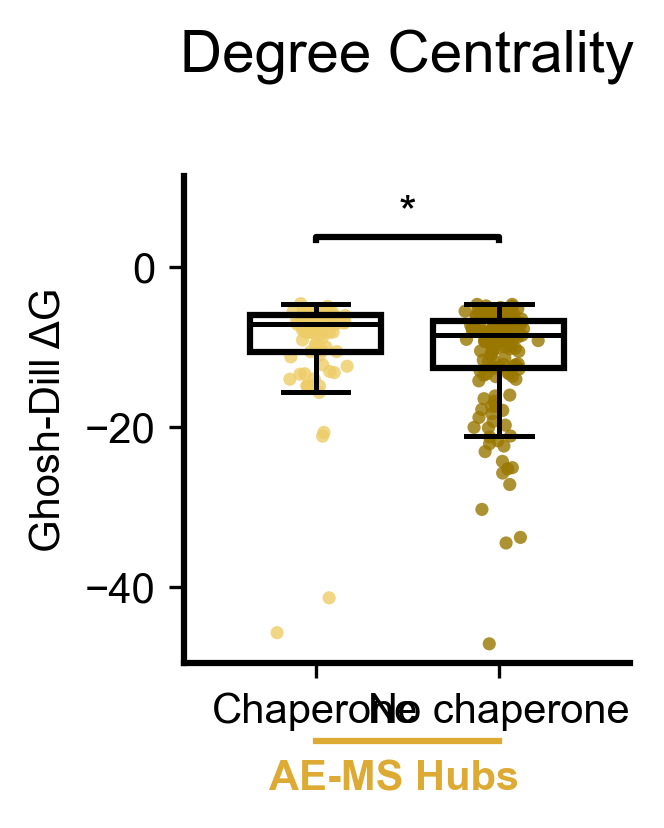

In [14]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone", "No chaperone"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Ghosh-Dill ΔG")
ax.set_title("Degree Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(hub_chap.min(), hub_nochap.min())
y_max = max(hub_chap.max(), hub_nochap.max())

# Significance bracket slightly above the highest data point
bracket_y = y_max + 8

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(y_min * 1.05, bracket_y + 8)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "*")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.16, -0.16],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.3, -0.20, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6.svg")
plt.show()

In [15]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

#Compute hub + chaperone groups for Ghosh–Dill ΔG
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (degree-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

print(f"Hub + Chaperone: n={len(hub_chap)}")
print(f"Hub + No Chaperone: n={len(hub_nochap)}")

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Hub + Chaperone: n=82
Hub + No Chaperone: n=170


Bootstrapping medians: 100%|███████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74725.39it/s]


Hub + Chaperone: median=-9.99, 95% CI=(-11.36, -8.06), n=82)


Bootstrapping medians: 100%|███████████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 68820.68it/s]

Hub + No Chaperone: median=-12.86, 95% CI=(-13.79, -10.93), n=170)


In [16]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on cagiada-dG ===")

print("\nHub + Chaperone vs Hub + NoChaperone")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on cagiada-dG ===

Hub + Chaperone vs Hub + NoChaperone
n(chap) = 82, n(nochap) = 170
median(chap) = -9.99, median(nochap) = -12.86
U = 7532.00, p = 0.3003


/tmp/ipykernel_1324/3778886098.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


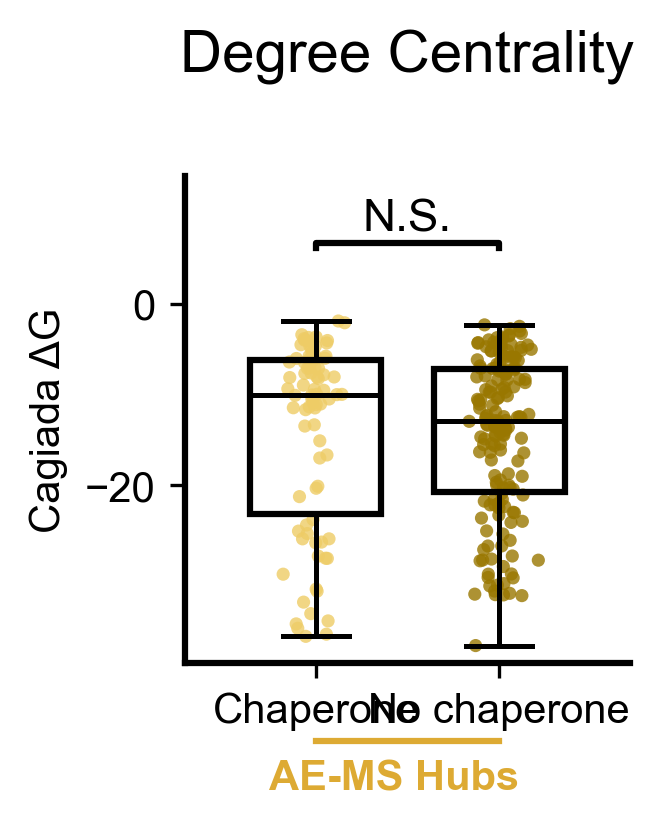

In [17]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone", "No chaperone"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Cagiada ΔG")
ax.set_title("Degree Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(hub_chap.min(), hub_nochap.min())
y_max = max(hub_chap.max(), hub_nochap.max())

# Significance bracket slightly above the highest data point
bracket_y = y_max + 8

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(y_min * 1.05, bracket_y + 8)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.16, -0.16],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.3, -0.20, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6.svg")
plt.show()

In [18]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

#Compute hub + chaperone groups for Ghosh–Dill ΔG
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (degree-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

print(f"Hub + Chaperone: n={len(hub_chap)}")
print(f"Hub + No Chaperone: n={len(hub_nochap)}")

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Hub + Chaperone: n=82
Hub + No Chaperone: n=170


Bootstrapping medians: 100%|███████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74678.10it/s]


Hub + Chaperone: median=-537.69, 95% CI=(-669.16, -451.99), n=82)


Bootstrapping medians: 100%|███████████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 69613.24it/s]

Hub + No Chaperone: median=-746.83, 95% CI=(-816.20, -654.67), n=170)


In [19]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Rosetta_best_total_score ===")

print("\nHub + Chaperone vs Hub + NoChaperone")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Rosetta_best_total_score ===

Hub + Chaperone vs Hub + NoChaperone
n(chap) = 82, n(nochap) = 170
median(chap) = -537.69, median(nochap) = -746.83
U = 8112.00, p = 0.03524


/tmp/ipykernel_1324/522566771.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


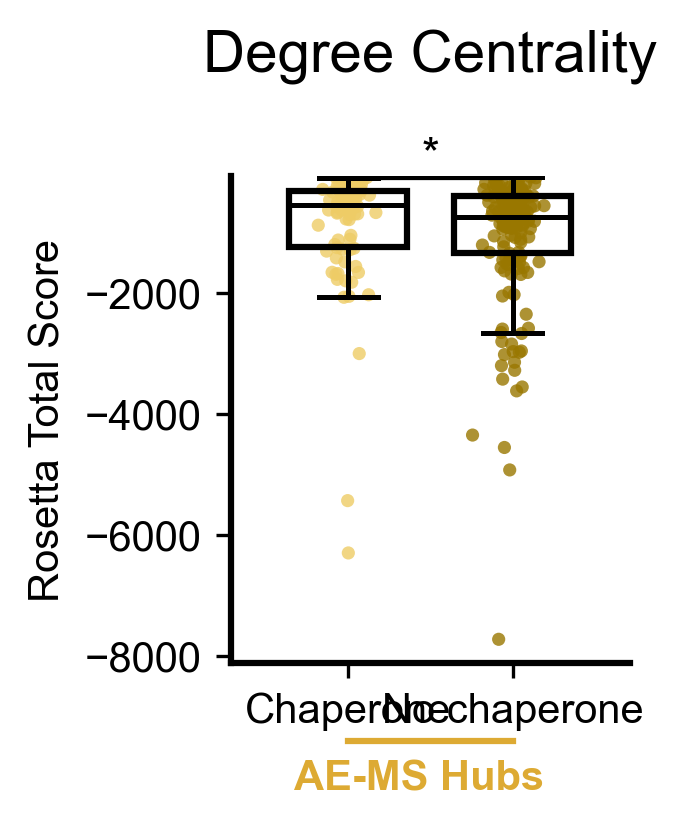

In [21]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone", "No chaperone"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Rosetta Total Score")
ax.set_title("Degree Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(hub_chap.min(), hub_nochap.min())
y_max = max(hub_chap.max(), hub_nochap.max())

# Significance bracket slightly above the highest data point
bracket_y = y_max + 8

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(y_min * 1.05, bracket_y + 8)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "*")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.16, -0.16],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.3, -0.20, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6.svg")
plt.show()

In [22]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

#Compute hub + chaperone groups for Ghosh–Dill ΔG
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (degree-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Ghosh–Dill values
hub_df["meltome-melting-point"] = hub_df[hub_df['meltome-fit-R2'] > 0.9]["meltome-melting-point"].replace([np.inf, -np.inf], np.nan).dropna()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

print(f"Hub + Chaperone: n={len(hub_chap)}")
print(f"Hub + No Chaperone: n={len(hub_nochap)}")

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Hub + Chaperone: n=69
Hub + No Chaperone: n=109


Bootstrapping medians: 100%|███████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74473.62it/s]


Hub + Chaperone: median=42.96, 95% CI=(42.37, 44.72), n=69)


Bootstrapping medians: 100%|███████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 73481.84it/s]

Hub + No Chaperone: median=44.91, 95% CI=(44.31, 47.51), n=109)


In [23]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on meltome-melting-point ===")

print("\nHub + Chaperone vs Hub + NoChaperone")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on meltome-melting-point ===

Hub + Chaperone vs Hub + NoChaperone
n(chap) = 69, n(nochap) = 109
median(chap) = 42.96, median(nochap) = 44.91
U = 2578.50, p = 0.0004195


/tmp/ipykernel_1324/3691543570.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


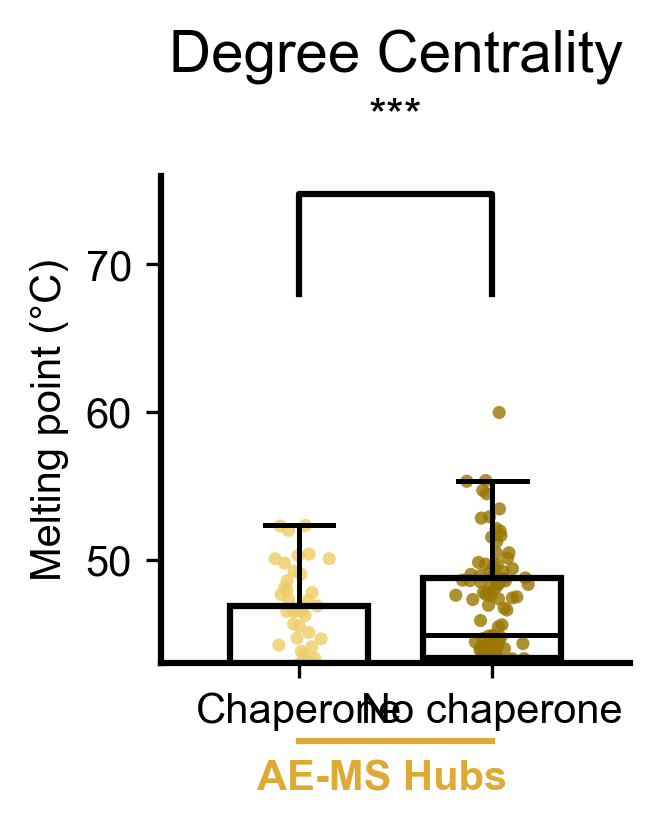

In [24]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone", "No chaperone"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Melting point (°C)")
ax.set_title("Degree Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(hub_chap.min(), hub_nochap.min())
y_max = max(hub_chap.max(), hub_nochap.max())

# Significance bracket slightly above the highest data point
bracket_y = y_max + 8

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(y_min * 1.05, bracket_y + 8)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.16, -0.16],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.3, -0.20, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6.svg")
plt.show()

In [25]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

#Compute hub + chaperone groups 
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (degree-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

print(f"Hub + Chaperone: n={len(hub_chap)}")
print(f"Hub + No Chaperone: n={len(hub_nochap)}")

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Hub + Chaperone: n=67
Hub + No Chaperone: n=157


Bootstrapping medians: 100%|███████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74126.89it/s]


Hub + Chaperone: median=91.80, 95% CI=(91.20, 92.40), n=67)


Bootstrapping medians: 100%|███████████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 69043.44it/s]


Hub + No Chaperone: median=88.80, 95% CI=(77.40, 91.20), n=157)


In [26]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Villen_halflife_min ===")

print("\nHub + Chaperone vs Hub + NoChaperone")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Villen_halflife_min ===

Hub + Chaperone vs Hub + NoChaperone
n(chap) = 67, n(nochap) = 157
median(chap) = 91.80, median(nochap) = 88.80
U = 6196.50, p = 0.03492


/tmp/ipykernel_1324/1031259780.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


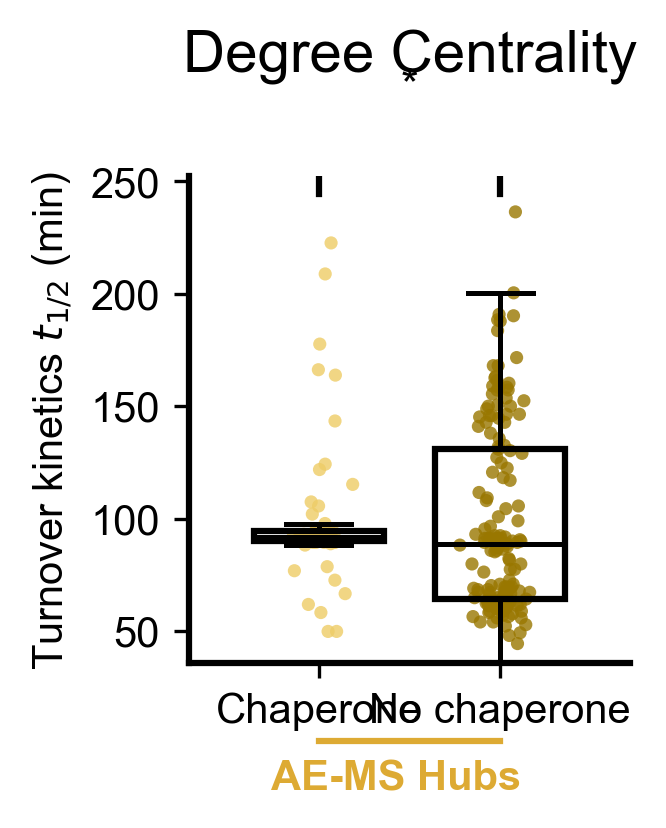

In [27]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone", "No chaperone"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Turnover kinetics $t_{1/2}$ (min)")
ax.set_title("Degree Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(hub_chap.min(), hub_nochap.min())
y_max = max(hub_chap.max(), hub_nochap.max())

# Significance bracket slightly above the highest data point
bracket_y = y_max + 8

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(y_min * 1.05, bracket_y + 8)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "*")

# === Horizontal line + label EXACTLY like your boss's style ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.16, -0.16],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)

ax.text(
    1.3, -0.20, "AE-MS Hubs",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}6.svg")
plt.show()

In [28]:
# Prepare Static/Dynamic + Chaperone Groups for Turnover t1/2

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")


# ================================================================
# Bootstrapped medians (boss-style)
# ================================================================
print("\n=== Bootstrapped median half-life (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} min, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 21
Static + NoChap   : n = 102
Dynamic + Chap    : n = 46
Dynamic + NoChap  : n = 55

=== Bootstrapped median half-life (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 77908.21it/s]


Static + Chap     : median = 91.8 min, 95% CI = (91.2, 105.6)


Bootstrapping medians: 100%|███████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 73141.56it/s]


Static + NoChap   : median = 90.6 min, 95% CI = (81.6, 117.0)


Bootstrapping medians: 100%|███████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 76161.94it/s]


Dynamic + Chap    : median = 91.2 min, 95% CI = (90.6, 92.4)


Bootstrapping medians: 100%|███████████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 76821.27it/s]

Dynamic + NoChap  : median = 72.6 min, 95% CI = (63.6, 90.0)


In [31]:
# ================================================================
# Mann–Whitney U tests — 4 comparisons
# ================================================================
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1256.0, p=0.215, significance=ns
Dynamic+Chap vs Dynamic+NoChap: U=1751.5, p=0.000908, significance=***
Static+Chap vs Dynamic+Chap   : U=611.5, p=0.0829, significance=ns
Static+NoChap vs Dynamic+NoChap: U=3744.5, p=0.00055, significance=***


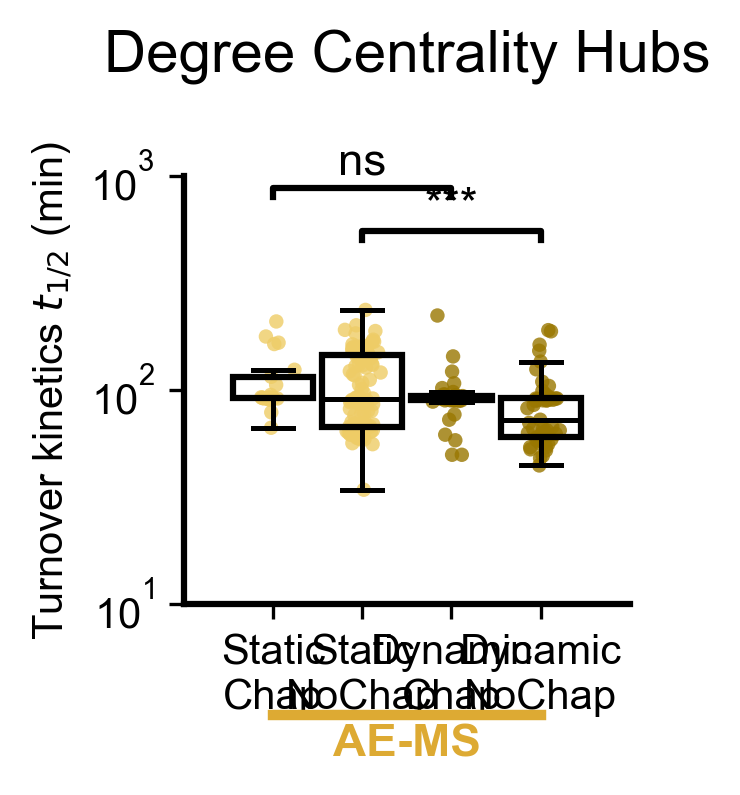

In [30]:
# Plot

fig, ax = plt.subplots(figsize=(2.3, 3))

positions = [1.0, 1.5, 2.0, 2.5]
group_data   = [static_chap, static_nochap, dynamic_chap, dynamic_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_LIGHT, MS_COLOR_DARK, MS_COLOR_DARK]
group_labels = ["Static\nChap", "Static\nNoChap", "Dynamic\nChap", "Dynamic\nNoChap"]

# Scatter (jitter)
for pos, (vals, color) in zip(positions, zip(group_data, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.04, size=len(vals))
    ax.scatter(x_jitter, vals, s=12, color=color,
               alpha=0.8, edgecolor="none", zorder=2)

# Boxplots
bp = ax.boxplot(
    group_data,
    tick_labels=group_labels,
    positions=positions,
    widths=0.45,
    patch_artist=True,
    showfliers=False
)

for box, color in zip(bp["boxes"], group_colors):
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# Styling
ax.set_yscale("log")
ax.set_ylim(1e1, 1e3)
ax.minorticks_off()
ax.set_ylabel(r'Turnover kinetics $t_{1/2}$ (min)')
ax.set_title("Degree Centrality Hubs")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Significance brackets — for the two comparisons
add_bracket_with_text(ax, 1.0, 2.0, 800, stars_chap)
add_bracket_with_text(ax, 1.5, 2.5, 500, stars_nochap)

# Bottom AE-MS label
trans = ax.get_xaxis_transform()
ax.plot([1.0, 2.5], [-0.26, -0.26], transform=trans, clip_on=False, color=MS_COLOR, lw=2.5)
ax.text(1.75, -0.28, "AE-MS", transform=trans, ha="center", va="top",
        fontsize=11, fontweight="bold", color=MS_COLOR)

plt.tight_layout()
plt.savefig(f"{OUT_PATH}6.svg", dpi=400, bbox_inches='tight')
plt.show()